In [2]:
# Data manipulation and analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

1) Clean the data in both of the provided datasets. landsat + terraclimate. Remove rows that have missing values.

In [3]:
# Load validation datasets
landsat_val = pd.read_csv('../Provided Datasets/landsat_features_validation.csv')
terraclimate_val = pd.read_csv('../Provided Datasets/terraclimate_features_validation.csv')

print("Landsat Validation - Before cleaning:")
print(f"Shape: {landsat_val.shape}")
print(f"Missing values:\n{landsat_val.isnull().sum()}")
print(f"\nRows with all feature columns missing: {landsat_val[['nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI']].isnull().all(axis=1).sum()}")

print("\n" + "="*50)
print("Terraclimate Validation - Before cleaning:")
print(f"Shape: {terraclimate_val.shape}")
print(f"Missing values:\n{terraclimate_val.isnull().sum()}")

# Clean landsat validation data
# Remove rows where all feature columns are missing
landsat_val_cleaned = landsat_val.dropna(subset=['nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI'], how='all')
# For rows with partial missing values, we'll keep them but note them
print(f"\nLandsat Validation - After removing rows with all features missing:")
print(f"Shape: {landsat_val_cleaned.shape}")
print(f"Removed {len(landsat_val) - len(landsat_val_cleaned)} rows")

# Clean terraclimate validation data
# Remove rows where pet is missing
terraclimate_val_cleaned = terraclimate_val.dropna(subset=['pet'])
print(f"\nTerraclimate Validation - After removing rows with missing pet:")
print(f"Shape: {terraclimate_val_cleaned.shape}")
print(f"Removed {len(terraclimate_val) - len(terraclimate_val_cleaned)} rows")

print("\nData cleaning completed!")

Landsat Validation - Before cleaning:
Shape: (200, 9)
Missing values:
Latitude        0
Longitude       0
Sample Date     0
nir            19
green          19
swir16         19
swir22         19
NDMI           19
MNDWI          19
dtype: int64

Rows with all feature columns missing: 19

Terraclimate Validation - Before cleaning:
Shape: (200, 4)
Missing values:
Latitude       0
Longitude      0
Sample Date    0
pet            0
dtype: int64

Landsat Validation - After removing rows with all features missing:
Shape: (181, 9)
Removed 19 rows

Terraclimate Validation - After removing rows with missing pet:
Shape: (200, 4)
Removed 0 rows

Data cleaning completed!


In [4]:
# Load training datasets
landsat_train = pd.read_csv('../Provided Datasets/landsat_features_training.csv')
terraclimate_train = pd.read_csv('../Provided Datasets/terraclimate_features_training.csv')

print("Landsat Training - Before cleaning:")
print(f"Shape: {landsat_train.shape}")
print(f"Missing values:\n{landsat_train.isnull().sum()}")
print(f"\nRows with all feature columns missing: {landsat_train[['nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI']].isnull().all(axis=1).sum()}")

print("\n" + "="*50)
print("Terraclimate Training - Before cleaning:")
print(f"Shape: {terraclimate_train.shape}")
print(f"Missing values:\n{terraclimate_train.isnull().sum()}")

# Clean landsat training data
# Remove rows where all feature columns are missing
landsat_train_cleaned = landsat_train.dropna(subset=['nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI'], how='all')
print(f"\nLandsat Training - After removing rows with all features missing:")
print(f"Shape: {landsat_train_cleaned.shape}")
print(f"Removed {len(landsat_train) - len(landsat_train_cleaned)} rows")

# Clean terraclimate training data
# Remove rows where pet is missing
terraclimate_train_cleaned = terraclimate_train.dropna(subset=['pet'])
print(f"\nTerraclimate Training - After removing rows with missing pet:")
print(f"Shape: {terraclimate_train_cleaned.shape}")
print(f"Removed {len(terraclimate_train) - len(terraclimate_train_cleaned)} rows")

# Also remove rows with missing coordinates for both datasets
landsat_train_cleaned = landsat_train_cleaned.dropna(subset=['Latitude', 'Longitude'])
terraclimate_train_cleaned = terraclimate_train_cleaned.dropna(subset=['Latitude', 'Longitude'])

print(f"\nAfter removing rows with missing coordinates:")
print(f"Landsat Training - Final shape: {landsat_train_cleaned.shape}")
print(f"Terraclimate Training - Final shape: {terraclimate_train_cleaned.shape}")

print("\nTraining data cleaning completed!")

Landsat Training - Before cleaning:
Shape: (9319, 9)
Missing values:
Latitude          0
Longitude         0
Sample Date       0
nir            1085
green          1085
swir16         1085
swir22         1085
NDMI           1085
MNDWI          1085
dtype: int64

Rows with all feature columns missing: 1085

Terraclimate Training - Before cleaning:
Shape: (9319, 4)
Missing values:
Latitude       0
Longitude      0
Sample Date    0
pet            0
dtype: int64

Landsat Training - After removing rows with all features missing:
Shape: (8234, 9)
Removed 1085 rows

Terraclimate Training - After removing rows with missing pet:
Shape: (9319, 4)
Removed 0 rows

After removing rows with missing coordinates:
Landsat Training - Final shape: (8234, 9)
Terraclimate Training - Final shape: (9319, 4)

Training data cleaning completed!


2) Show the distribution of the pet feature in terracliamte


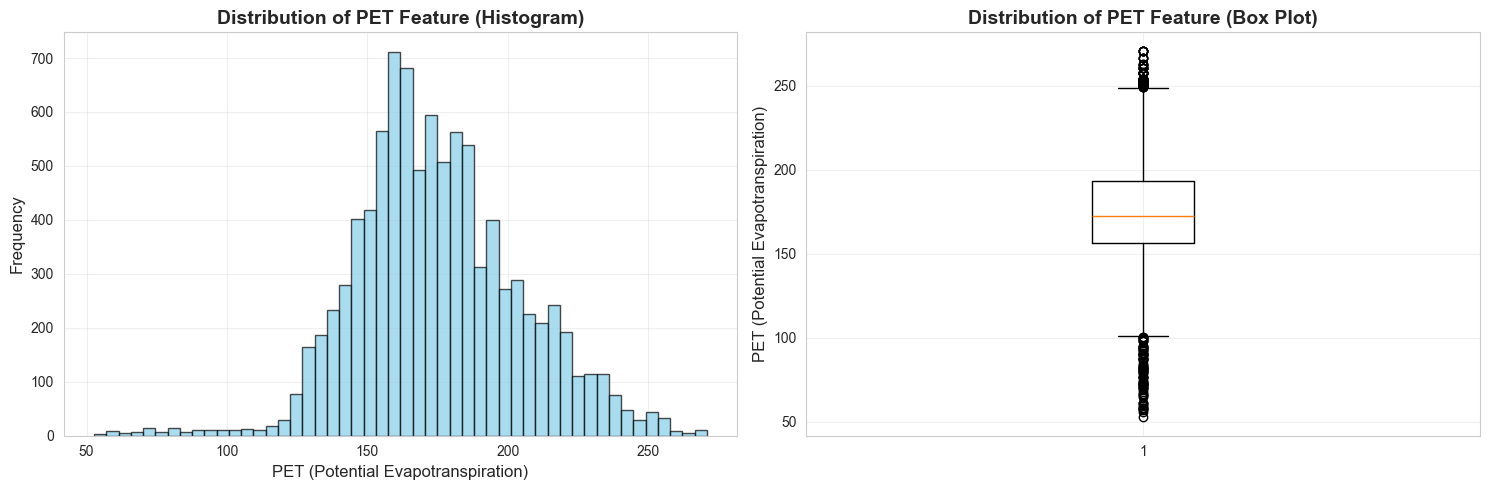

PET Feature Statistics:
count    9319.000000
mean      175.166082
std        29.469867
min        52.700000
25%       156.100000
50%       172.500000
75%       193.100000
max       270.800020
Name: pet, dtype: float64

Total samples: 9319
Missing values: 0


In [5]:
# Use the cleaned training data from the cleaning step above
# terraclimate_train_cleaned is already available from the cleaning cell

# Create distribution plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(terraclimate_train_cleaned['pet'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('PET (Potential Evapotranspiration)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of PET Feature (Histogram)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(terraclimate_train_cleaned['pet'], vert=True)
axes[1].set_ylabel('PET (Potential Evapotranspiration)', fontsize=12)
axes[1].set_title('Distribution of PET Feature (Box Plot)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("PET Feature Statistics:")
print(terraclimate_train_cleaned['pet'].describe())
print(f"\nTotal samples: {len(terraclimate_train_cleaned)}")
print(f"Missing values: {terraclimate_train_cleaned['pet'].isnull().sum()}")

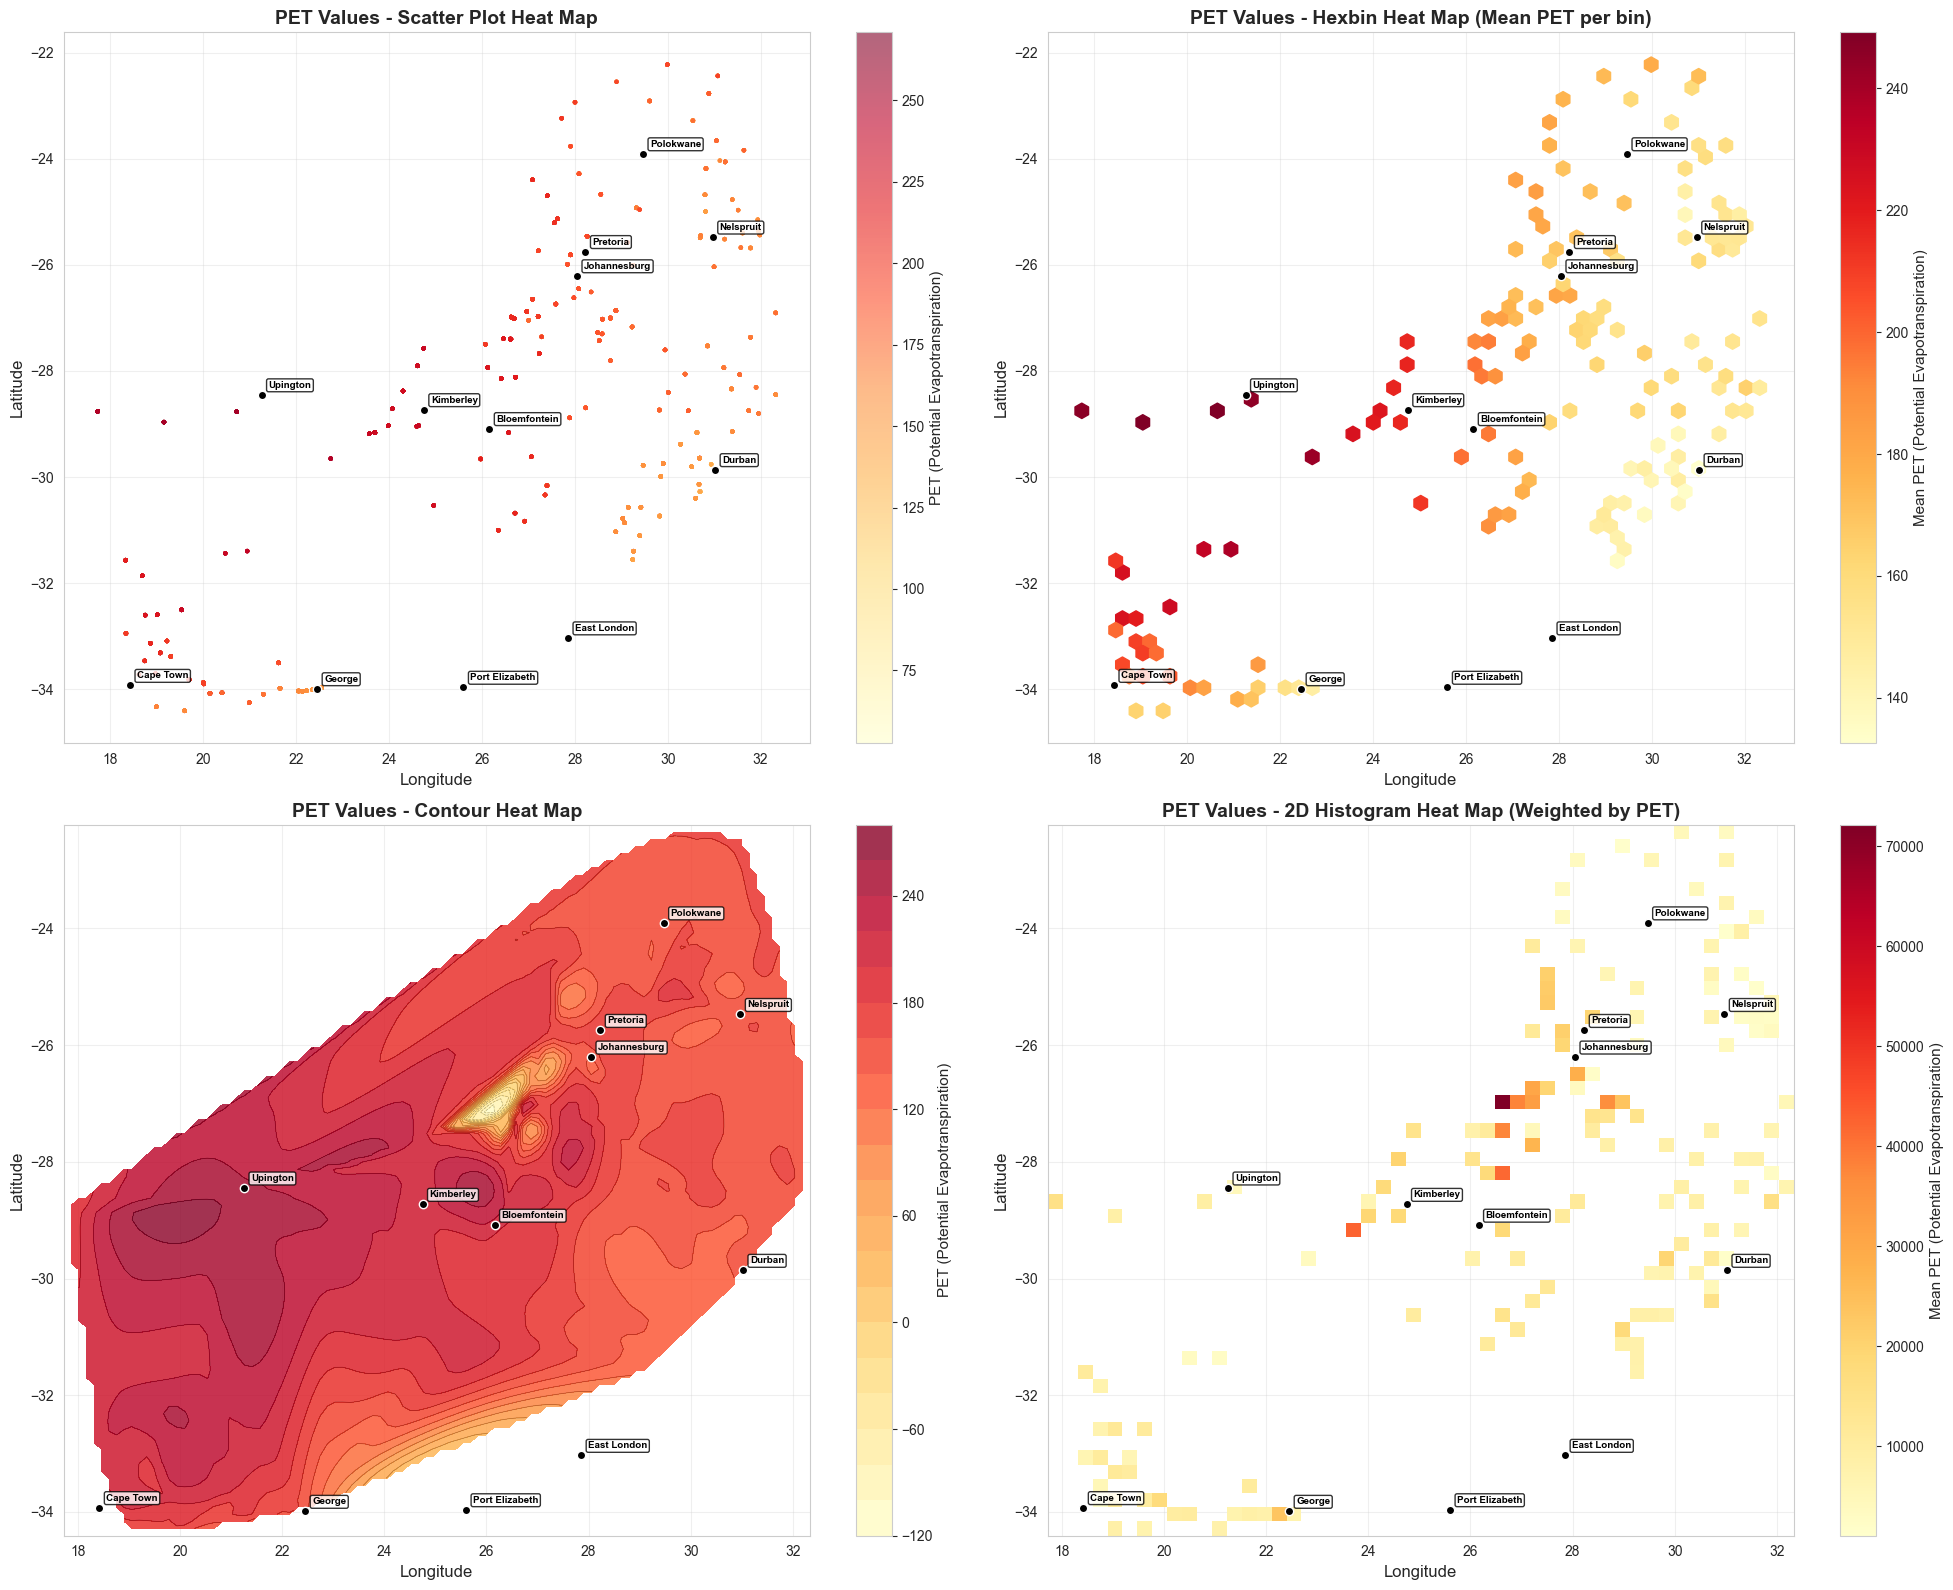


PET VALUE SUMMARY BY GEOGRAPHIC REGION

Overall Statistics:
  Mean PET: 175.17
  Min PET: 52.70
  Max PET: 270.80
  Std PET: 29.47

By Latitude Quadrants:
  Northwest: Mean PET = 184.85 (n=1795)
  Northeast: Mean PET = 164.13 (n=2862)
  Southwest: Mean PET = 197.42 (n=2861)
  Southeast: Mean PET = 147.70 (n=1801)


In [6]:
# Create a heat map showing PET values across geographic locations

# Use the cleaned training data
# terraclimate_train_cleaned is already available from the cleaning cell

# Define prominent South African cities with their coordinates (for reference on map)
south_african_cities = {
    'Cape Town': [-33.9249, 18.4241],
    'Johannesburg': [-26.2041, 28.0473],
    'Durban': [-29.8587, 31.0218],
    'Pretoria': [-25.7479, 28.2293],
    'Port Elizabeth': [-33.9608, 25.6022],
    'Bloemfontein': [-29.0852, 26.1596],
    'East London': [-33.0292, 27.8546],
    'Polokwane': [-23.9045, 29.4689],
    'Nelspruit': [-25.4745, 30.9703],
    'Kimberley': [-28.7282, 24.7497],
    'George': [-33.9881, 22.4536],
    'Upington': [-28.4478, 21.2561]
}

# Create figure with multiple visualization styles
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Scatter plot colored by PET values
scatter = axes[0, 0].scatter(terraclimate_train_cleaned['Longitude'], 
                             terraclimate_train_cleaned['Latitude'], 
                             c=terraclimate_train_cleaned['pet'], 
                             cmap='YlOrRd', s=10, alpha=0.6, edgecolors='none')
axes[0, 0].set_xlabel('Longitude', fontsize=12)
axes[0, 0].set_ylabel('Latitude', fontsize=12)
axes[0, 0].set_title('PET Values - Scatter Plot Heat Map', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter, ax=axes[0, 0])
cbar1.set_label('PET (Potential Evapotranspiration)', fontsize=11)

# Add city markers
for city_name, (lat, lon) in south_african_cities.items():
    axes[0, 0].plot(lon, lat, 'ko', markersize=6, markeredgecolor='white', markeredgewidth=1)
    axes[0, 0].annotate(city_name, (lon, lat), xytext=(5, 5), textcoords='offset points', 
                       fontsize=7, fontweight='bold', color='black',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='black'))

# 2. Hexbin plot showing density and PET values
hexbin = axes[0, 1].hexbin(terraclimate_train_cleaned['Longitude'], 
                           terraclimate_train_cleaned['Latitude'], 
                           C=terraclimate_train_cleaned['pet'],
                           gridsize=50, cmap='YlOrRd', reduce_C_function=np.mean, mincnt=1)
axes[0, 1].set_xlabel('Longitude', fontsize=12)
axes[0, 1].set_ylabel('Latitude', fontsize=12)
axes[0, 1].set_title('PET Values - Hexbin Heat Map (Mean PET per bin)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(hexbin, ax=axes[0, 1])
cbar2.set_label('Mean PET (Potential Evapotranspiration)', fontsize=11)

# Add city markers
for city_name, (lat, lon) in south_african_cities.items():
    axes[0, 1].plot(lon, lat, 'ko', markersize=6, markeredgecolor='white', markeredgewidth=1)
    axes[0, 1].annotate(city_name, (lon, lat), xytext=(5, 5), textcoords='offset points', 
                       fontsize=7, fontweight='bold', color='black',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='black'))

# 3. Contour plot of PET values
from scipy.interpolate import griddata

# Create a grid for interpolation
lon_min, lon_max = terraclimate_train_cleaned['Longitude'].min(), terraclimate_train_cleaned['Longitude'].max()
lat_min, lat_max = terraclimate_train_cleaned['Latitude'].min(), terraclimate_train_cleaned['Latitude'].max()
lon_grid = np.linspace(lon_min, lon_max, 100)
lat_grid = np.linspace(lat_min, lat_max, 100)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Interpolate PET values onto the grid
pet_grid = griddata((terraclimate_train_cleaned['Longitude'], terraclimate_train_cleaned['Latitude']),
                    terraclimate_train_cleaned['pet'],
                    (lon_mesh, lat_mesh), method='cubic')

# Create contour plot
contour = axes[1, 0].contourf(lon_mesh, lat_mesh, pet_grid, levels=20, cmap='YlOrRd', alpha=0.8)
axes[1, 0].contour(lon_mesh, lat_mesh, pet_grid, levels=20, colors='black', alpha=0.3, linewidths=0.5)
axes[1, 0].set_xlabel('Longitude', fontsize=12)
axes[1, 0].set_ylabel('Latitude', fontsize=12)
axes[1, 0].set_title('PET Values - Contour Heat Map', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
cbar3 = plt.colorbar(contour, ax=axes[1, 0])
cbar3.set_label('PET (Potential Evapotranspiration)', fontsize=11)

# Add city markers
for city_name, (lat, lon) in south_african_cities.items():
    axes[1, 0].plot(lon, lat, 'ko', markersize=6, markeredgecolor='white', markeredgewidth=1)
    axes[1, 0].annotate(city_name, (lon, lat), xytext=(5, 5), textcoords='offset points', 
                       fontsize=7, fontweight='bold', color='black',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='black'))

# 4. 2D Histogram/Heat map
hist2d = axes[1, 1].hist2d(terraclimate_train_cleaned['Longitude'], 
                           terraclimate_train_cleaned['Latitude'], 
                           bins=50, 
                           weights=terraclimate_train_cleaned['pet'],
                           cmap='YlOrRd', 
                           cmin=1)
axes[1, 1].set_xlabel('Longitude', fontsize=12)
axes[1, 1].set_ylabel('Latitude', fontsize=12)
axes[1, 1].set_title('PET Values - 2D Histogram Heat Map (Weighted by PET)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
cbar4 = plt.colorbar(hist2d[3], ax=axes[1, 1])
cbar4.set_label('Mean PET (Potential Evapotranspiration)', fontsize=11)

# Add city markers
for city_name, (lat, lon) in south_african_cities.items():
    axes[1, 1].plot(lon, lat, 'ko', markersize=6, markeredgecolor='white', markeredgewidth=1)
    axes[1, 1].annotate(city_name, (lon, lat), xytext=(5, 5), textcoords='offset points', 
                       fontsize=7, fontweight='bold', color='black',
                       bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='black'))

plt.tight_layout()
plt.show()

# Print summary statistics by geographic region
print("\n" + "="*70)
print("PET VALUE SUMMARY BY GEOGRAPHIC REGION")
print("="*70)
print(f"\nOverall Statistics:")
print(f"  Mean PET: {terraclimate_train_cleaned['pet'].mean():.2f}")
print(f"  Min PET: {terraclimate_train_cleaned['pet'].min():.2f}")
print(f"  Max PET: {terraclimate_train_cleaned['pet'].max():.2f}")
print(f"  Std PET: {terraclimate_train_cleaned['pet'].std():.2f}")

# Geographic quadrants
print(f"\nBy Latitude Quadrants:")
lat_median = terraclimate_train_cleaned['Latitude'].median()
lon_median = terraclimate_train_cleaned['Longitude'].median()

nw = terraclimate_train_cleaned[(terraclimate_train_cleaned['Latitude'] > lat_median) & 
                                (terraclimate_train_cleaned['Longitude'] < lon_median)]
ne = terraclimate_train_cleaned[(terraclimate_train_cleaned['Latitude'] > lat_median) & 
                                (terraclimate_train_cleaned['Longitude'] >= lon_median)]
sw = terraclimate_train_cleaned[(terraclimate_train_cleaned['Latitude'] <= lat_median) & 
                                (terraclimate_train_cleaned['Longitude'] < lon_median)]
se = terraclimate_train_cleaned[(terraclimate_train_cleaned['Latitude'] <= lat_median) & 
                                (terraclimate_train_cleaned['Longitude'] >= lon_median)]

print(f"  Northwest: Mean PET = {nw['pet'].mean():.2f} (n={len(nw)})")
print(f"  Northeast: Mean PET = {ne['pet'].mean():.2f} (n={len(ne)})")
print(f"  Southwest: Mean PET = {sw['pet'].mean():.2f} (n={len(sw)})")
print(f"  Southeast: Mean PET = {se['pet'].mean():.2f} (n={len(se)})")

3) Show a heat map of the latitude and longitude on a map in both terraclimate_features_training.csv and landsat_features_training.csv


Creating heat map for Terraclimate training data...
Terraclimate heat map saved to terraclimate_training_heatmap.html

Creating heat map for Landsat training data...
Landsat heat map saved to landsat_training_heatmap.html


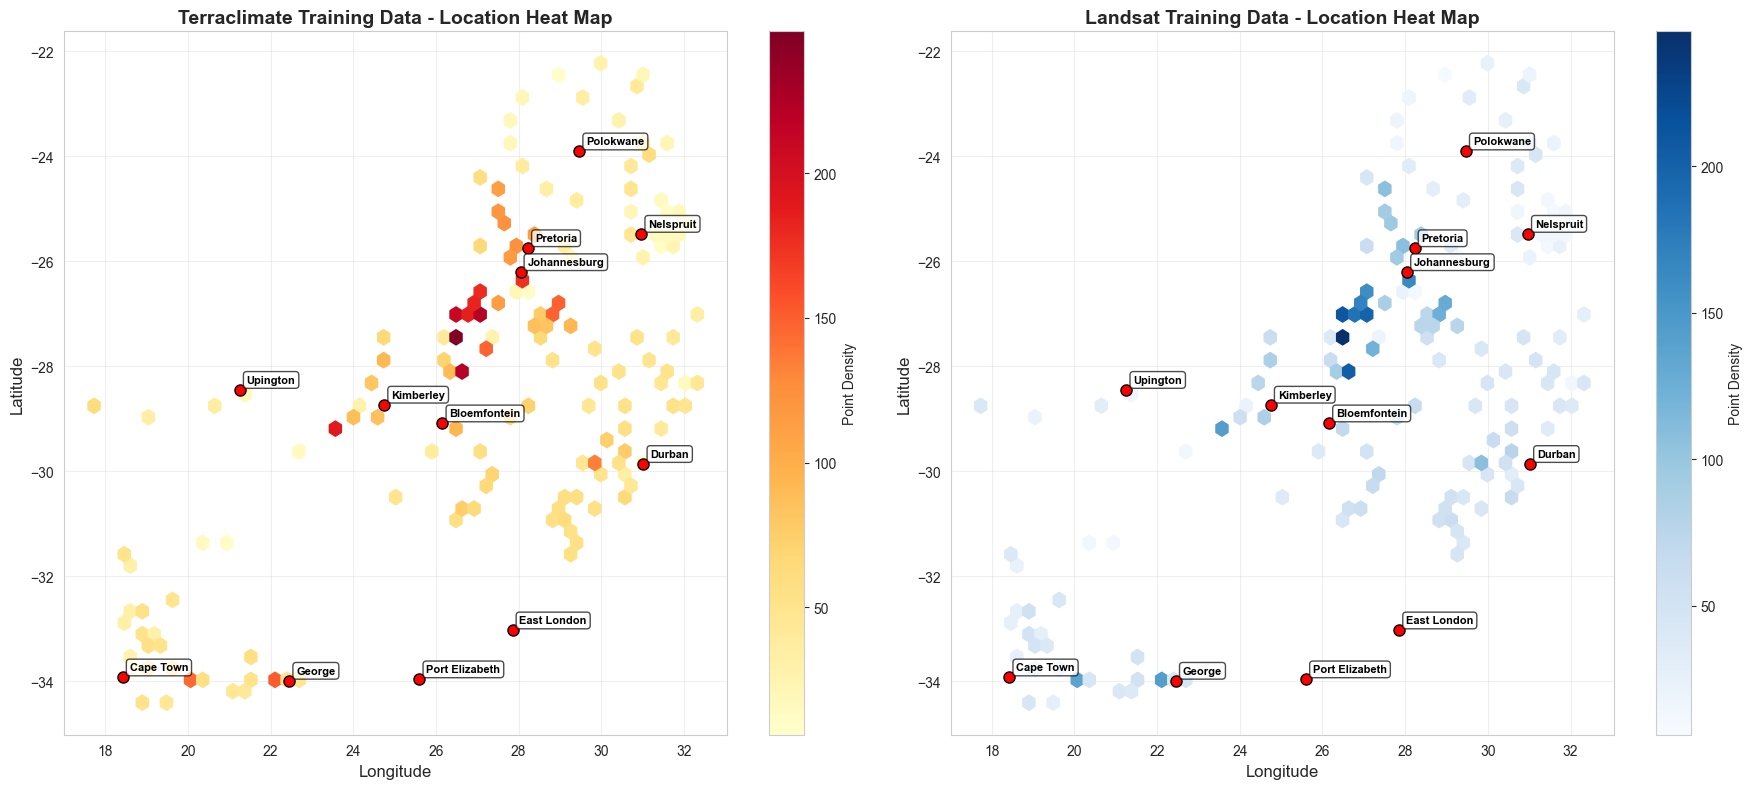


Terraclimate Training Data:
  Total samples: 9319
  Latitude range: [-34.41, -22.23]
  Longitude range: [17.73, 32.33]

Landsat Training Data:
  Total samples: 8234
  Latitude range: [-34.41, -22.23]
  Longitude range: [17.73, 32.33]


In [7]:
# Use the cleaned training data from the cleaning step above
# landsat_train_cleaned and terraclimate_train_cleaned are already available

# Calculate center of the data for map initialization
lat_center = (landsat_train_cleaned['Latitude'].mean() + terraclimate_train_cleaned['Latitude'].mean()) / 2
lon_center = (landsat_train_cleaned['Longitude'].mean() + terraclimate_train_cleaned['Longitude'].mean()) / 2

# Define prominent South African cities with their coordinates
south_african_cities = {
    'Cape Town': [-33.9249, 18.4241],
    'Johannesburg': [-26.2041, 28.0473],
    'Durban': [-29.8587, 31.0218],
    'Pretoria': [-25.7479, 28.2293],
    'Port Elizabeth': [-33.9608, 25.6022],
    'Bloemfontein': [-29.0852, 26.1596],
    'East London': [-33.0292, 27.8546],
    'Polokwane': [-23.9045, 29.4689],
    'Nelspruit': [-25.4745, 30.9703],
    'Kimberley': [-28.7282, 24.7497],
    'George': [-33.9881, 22.4536],
    'Upington': [-28.4478, 21.2561]
}

# Create heat map for Terraclimate training data
print("Creating heat map for Terraclimate training data...")
map_terraclimate = folium.Map(location=[lat_center, lon_center], zoom_start=6, tiles='OpenStreetMap')

# Prepare heat data
heat_data_terraclimate = [[row['Latitude'], row['Longitude']] for idx, row in terraclimate_train_cleaned.iterrows()]

# Add heat map layer
HeatMap(heat_data_terraclimate, radius=15, blur=10, max_zoom=1).add_to(map_terraclimate)

# Add city markers
for city_name, (lat, lon) in south_african_cities.items():
    folium.Marker(
        location=[lat, lon],
        popup=city_name,
        tooltip=city_name,
        icon=folium.Icon(color='red', icon='info-sign', prefix='glyphicon')
    ).add_to(map_terraclimate)

# Save map
map_terraclimate.save('../Our Notebooks/utils/terraclimate_training_heatmap.html')
print("Terraclimate heat map saved to terraclimate_training_heatmap.html")

# Create heat map for Landsat training data
print("\nCreating heat map for Landsat training data...")
map_landsat = folium.Map(location=[lat_center, lon_center], zoom_start=6, tiles='OpenStreetMap')

# Prepare heat data
heat_data_landsat = [[row['Latitude'], row['Longitude']] for idx, row in landsat_train_cleaned.iterrows()]

# Add heat map layer
HeatMap(heat_data_landsat, radius=15, blur=10, max_zoom=1).add_to(map_landsat)

# Add city markers
for city_name, (lat, lon) in south_african_cities.items():
    folium.Marker(
        location=[lat, lon],
        popup=city_name,
        tooltip=city_name,
        icon=folium.Icon(color='red', icon='info-sign', prefix='glyphicon')
    ).add_to(map_landsat)

# Save map
map_landsat.save('../Our Notebooks/utils/landsat_training_heatmap.html')
print("Landsat heat map saved to landsat_training_heatmap.html")

# Also create a combined visualization using matplotlib/seaborn
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Terraclimate scatter density plot
axes[0].hexbin(terraclimate_train_cleaned['Longitude'], terraclimate_train_cleaned['Latitude'], 
               gridsize=50, cmap='YlOrRd', mincnt=1)
axes[0].set_xlabel('Longitude', fontsize=12)
axes[0].set_ylabel('Latitude', fontsize=12)
axes[0].set_title('Terraclimate Training Data - Location Heat Map', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
cb1 = plt.colorbar(axes[0].collections[0], ax=axes[0])
cb1.set_label('Point Density', fontsize=10)

# Add city markers to Terraclimate plot
for city_name, (lat, lon) in south_african_cities.items():
    axes[0].plot(lon, lat, 'ro', markersize=8, markeredgecolor='black', markeredgewidth=1)
    axes[0].annotate(city_name, (lon, lat), xytext=(5, 5), textcoords='offset points', 
                    fontsize=8, fontweight='bold', color='black',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='black'))

# Landsat scatter density plot
axes[1].hexbin(landsat_train_cleaned['Longitude'], landsat_train_cleaned['Latitude'], 
               gridsize=50, cmap='Blues', mincnt=1)
axes[1].set_xlabel('Longitude', fontsize=12)
axes[1].set_ylabel('Latitude', fontsize=12)
axes[1].set_title('Landsat Training Data - Location Heat Map', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
cb2 = plt.colorbar(axes[1].collections[0], ax=axes[1])
cb2.set_label('Point Density', fontsize=10)

# Add city markers to Landsat plot
for city_name, (lat, lon) in south_african_cities.items():
    axes[1].plot(lon, lat, 'ro', markersize=8, markeredgecolor='black', markeredgewidth=1)
    axes[1].annotate(city_name, (lon, lat), xytext=(5, 5), textcoords='offset points', 
                    fontsize=8, fontweight='bold', color='black',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='black'))

plt.tight_layout()
plt.show()

print(f"\nTerraclimate Training Data:")
print(f"  Total samples: {len(terraclimate_train_cleaned)}")
print(f"  Latitude range: [{terraclimate_train_cleaned['Latitude'].min():.2f}, {terraclimate_train_cleaned['Latitude'].max():.2f}]")
print(f"  Longitude range: [{terraclimate_train_cleaned['Longitude'].min():.2f}, {terraclimate_train_cleaned['Longitude'].max():.2f}]")

print(f"\nLandsat Training Data:")
print(f"  Total samples: {len(landsat_train_cleaned)}")
print(f"  Latitude range: [{landsat_train_cleaned['Latitude'].min():.2f}, {landsat_train_cleaned['Latitude'].max():.2f}]")
print(f"  Longitude range: [{landsat_train_cleaned['Longitude'].min():.2f}, {landsat_train_cleaned['Longitude'].max():.2f}]")

4) Show a distribution of the nir, green, swir16, swir22, ndmi, mndwi features in landsat_features_validation.csv


Plotting distributions for 181 samples with complete feature data


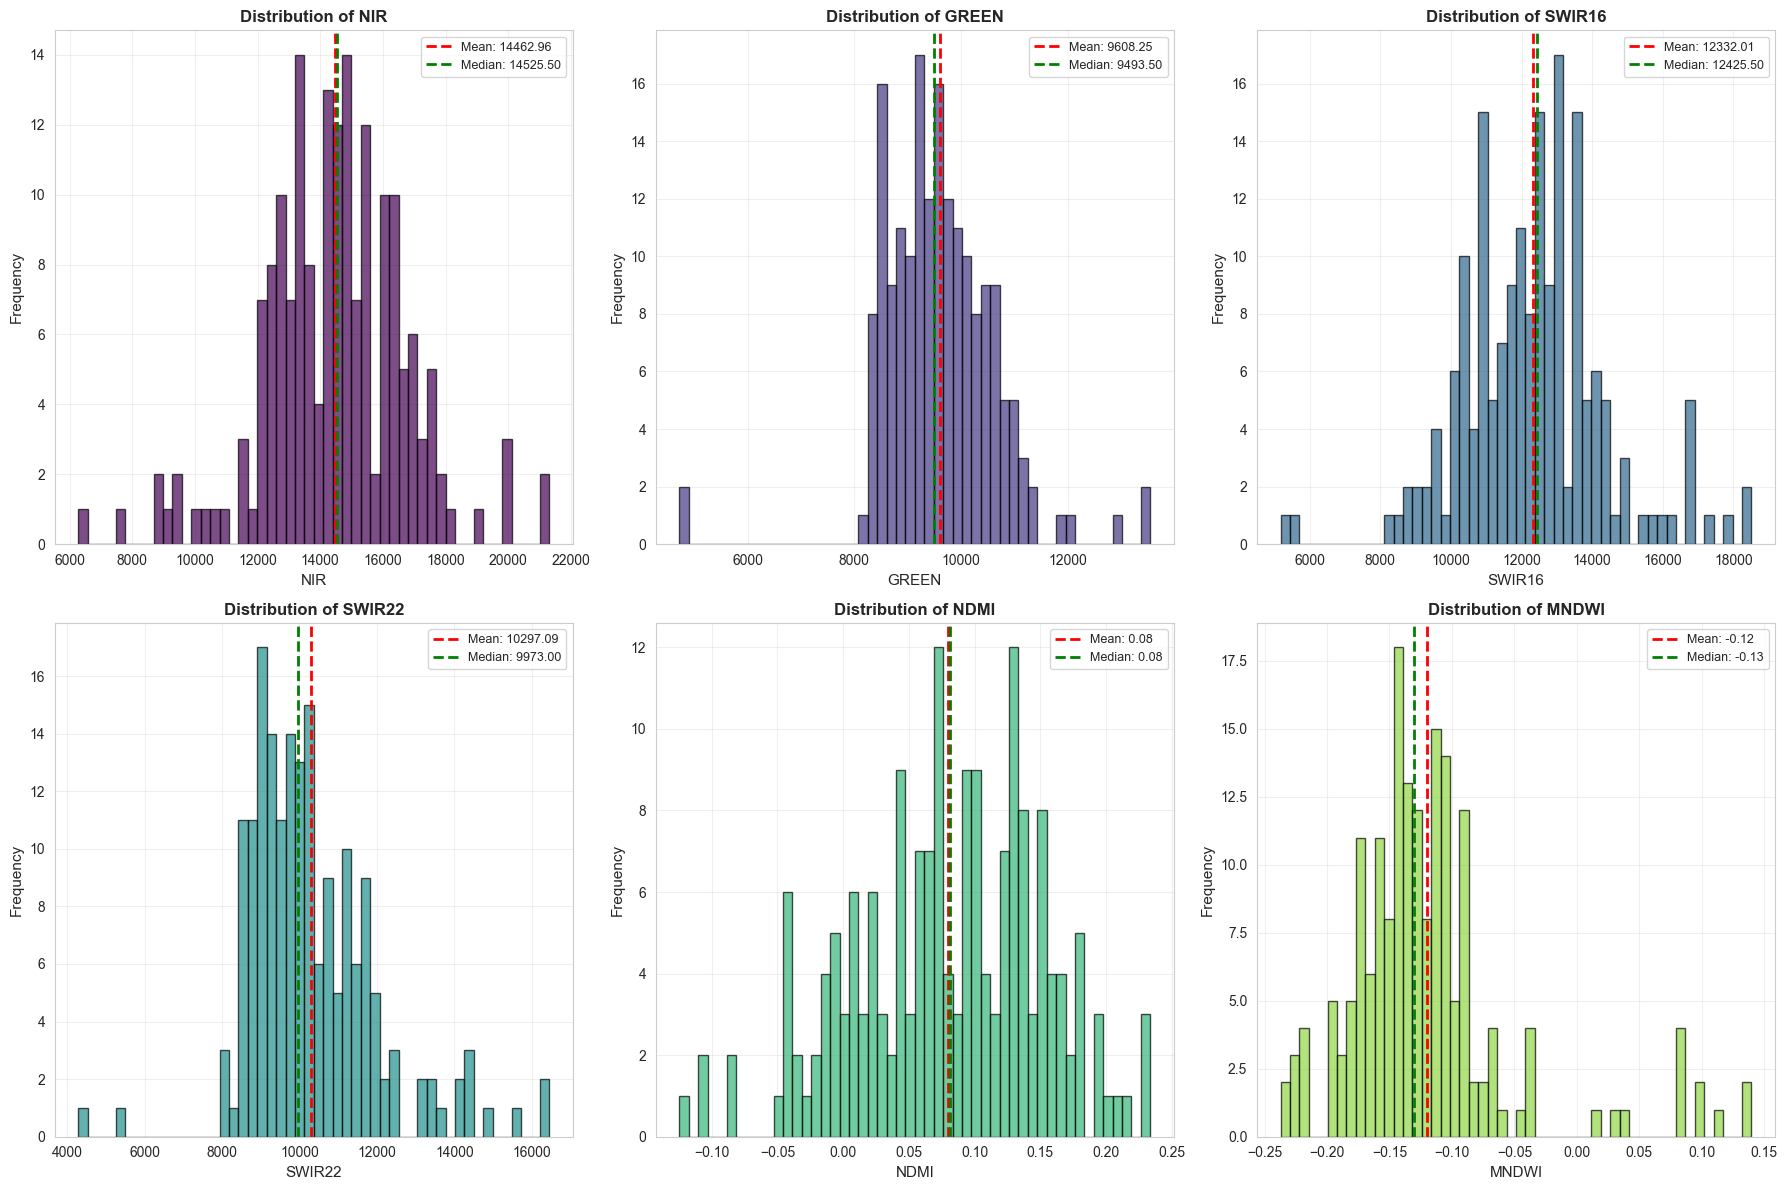

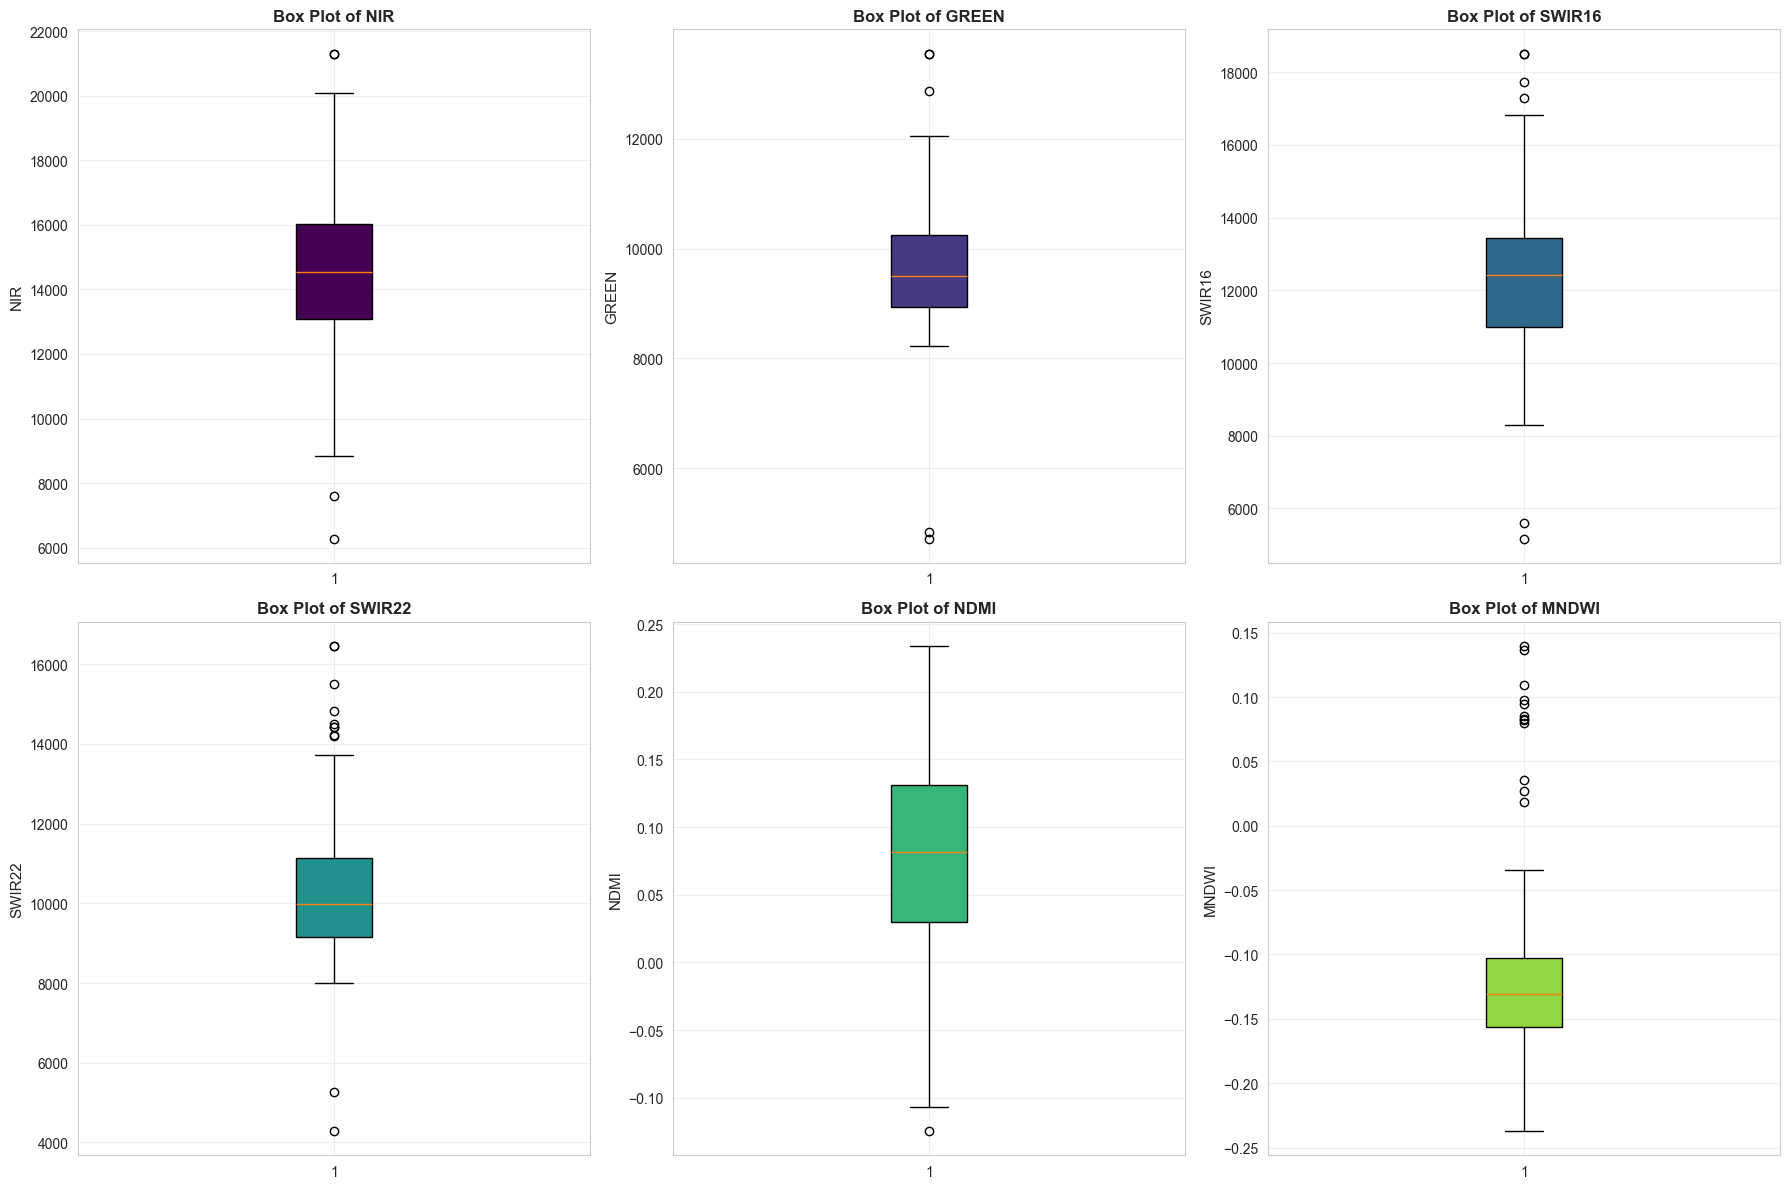


STATISTICAL SUMMARY OF LANDSAT VALIDATION FEATURES

NIR:
  Count: 181
  Mean: 14462.9558
  Median: 14525.5000
  Std: 2292.4889
  Min: 6281.0000
  Max: 21308.0000
  Missing values: 0

GREEN:
  Count: 181
  Mean: 9608.2541
  Median: 9493.5000
  Std: 1070.3556
  Min: 4715.5000
  Max: 13553.0000
  Missing values: 0

SWIR16:
  Count: 181
  Mean: 12332.0110
  Median: 12425.5000
  Std: 2031.5636
  Min: 5173.5000
  Max: 18512.5000
  Missing values: 0

SWIR22:
  Count: 181
  Mean: 10297.0884
  Median: 9973.0000
  Std: 1702.4975
  Min: 4286.5000
  Max: 16452.0000
  Missing values: 0

NDMI:
  Count: 181
  Mean: 0.0795
  Median: 0.0814
  Std: 0.0719
  Min: -0.1246
  Max: 0.2338
  Missing values: 0

MNDWI:
  Count: 181
  Mean: -0.1200
  Median: -0.1306
  Std: 0.0676
  Min: -0.2372
  Max: 0.1397
  Missing values: 0


In [8]:
# Use the cleaned validation data from step 0
# Remove rows where all these features are missing
features_to_plot = ['nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI']
landsat_val_for_plot = landsat_val_cleaned.dropna(subset=features_to_plot)

print(f"Plotting distributions for {len(landsat_val_for_plot)} samples with complete feature data")

# Create subplots for distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    # Remove missing values for this specific feature
    feature_data = landsat_val_for_plot[feature].dropna()
    
    # Create histogram
    axes[idx].hist(feature_data, bins=50, edgecolor='black', alpha=0.7, color=plt.cm.viridis(idx/len(features_to_plot)))
    axes[idx].set_xlabel(feature.upper(), fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'Distribution of {feature.upper()}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add statistics text
    mean_val = feature_data.mean()
    median_val = feature_data.median()
    std_val = feature_data.std()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Create box plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    feature_data = landsat_val_for_plot[feature].dropna()
    
    # Create box plot
    bp = axes[idx].boxplot(feature_data, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor(plt.cm.viridis(idx/len(features_to_plot)))
    axes[idx].set_ylabel(feature.upper(), fontsize=11)
    axes[idx].set_title(f'Box Plot of {feature.upper()}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics for all features
print("\n" + "="*70)
print("STATISTICAL SUMMARY OF LANDSAT VALIDATION FEATURES")
print("="*70)
for feature in features_to_plot:
    feature_data = landsat_val_for_plot[feature].dropna()
    print(f"\n{feature.upper()}:")
    print(f"  Count: {len(feature_data)}")
    print(f"  Mean: {feature_data.mean():.4f}")
    print(f"  Median: {feature_data.median():.4f}")
    print(f"  Std: {feature_data.std():.4f}")
    print(f"  Min: {feature_data.min():.4f}")
    print(f"  Max: {feature_data.max():.4f}")
    print(f"  Missing values: {landsat_val_cleaned[feature].isnull().sum()}")

Creating visualizations for 8234 samples with complete feature data
Features to visualize: nir, green, swir16, swir22, NDMI, MNDWI


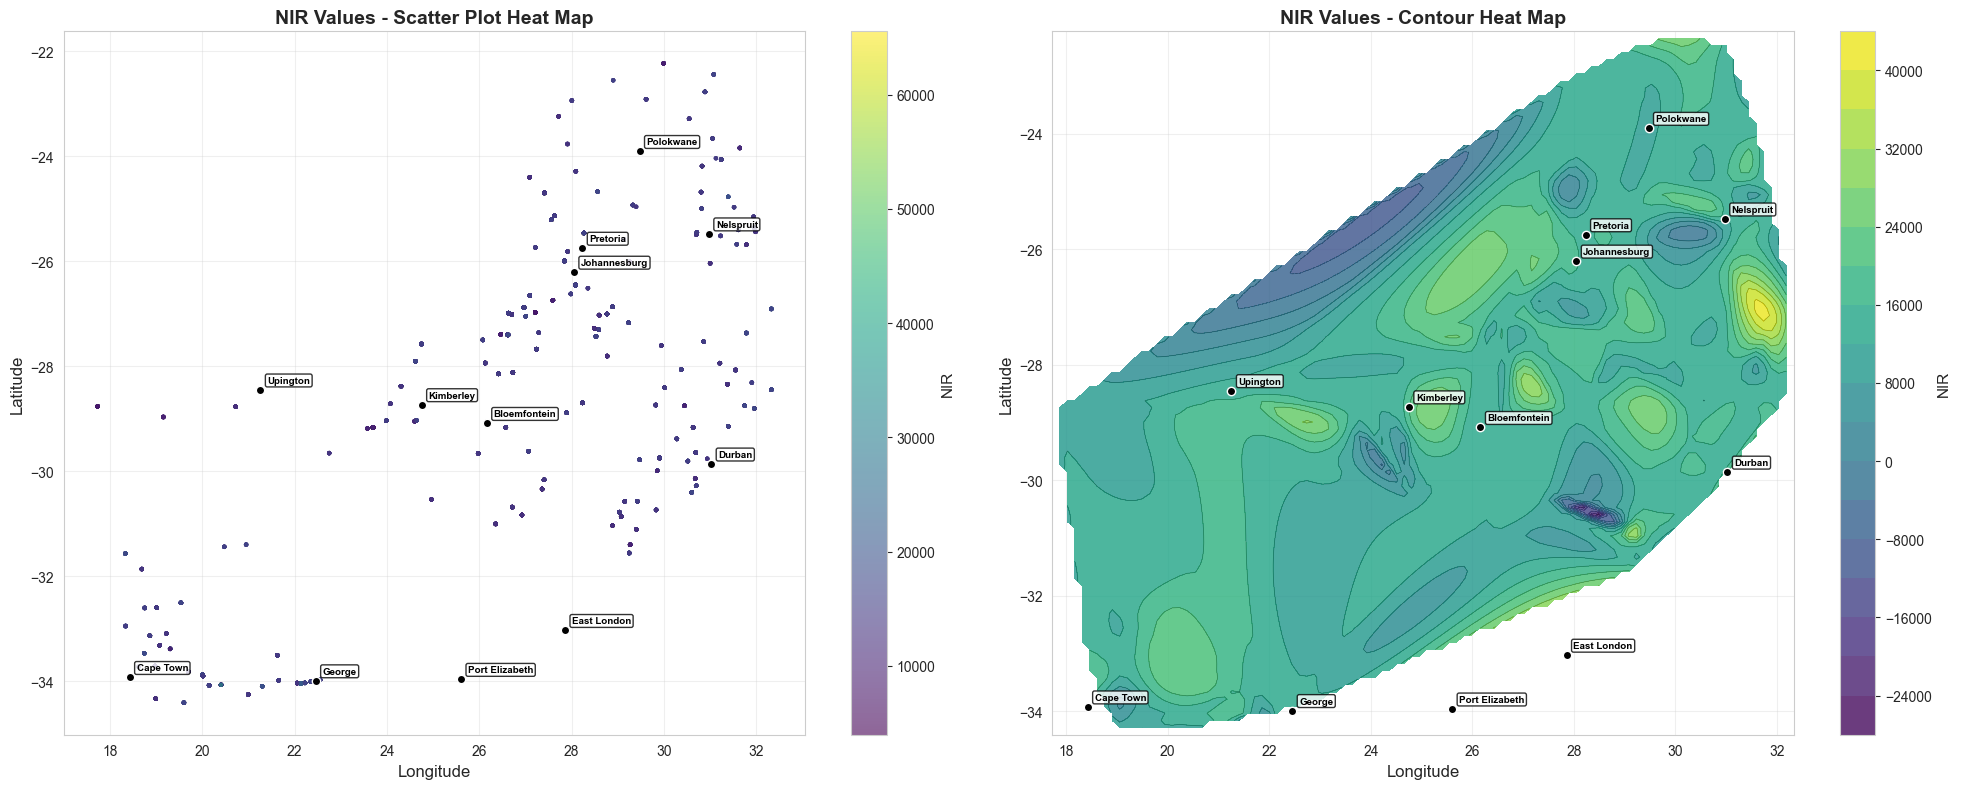


NIR Statistics:
  Count: 8234
  Mean: 14045.4854
  Median: 14183.0000
  Std: 2953.2236
  Min: 3992.0000
  Max: 65535.0000
  Missing values: 0
----------------------------------------------------------------------


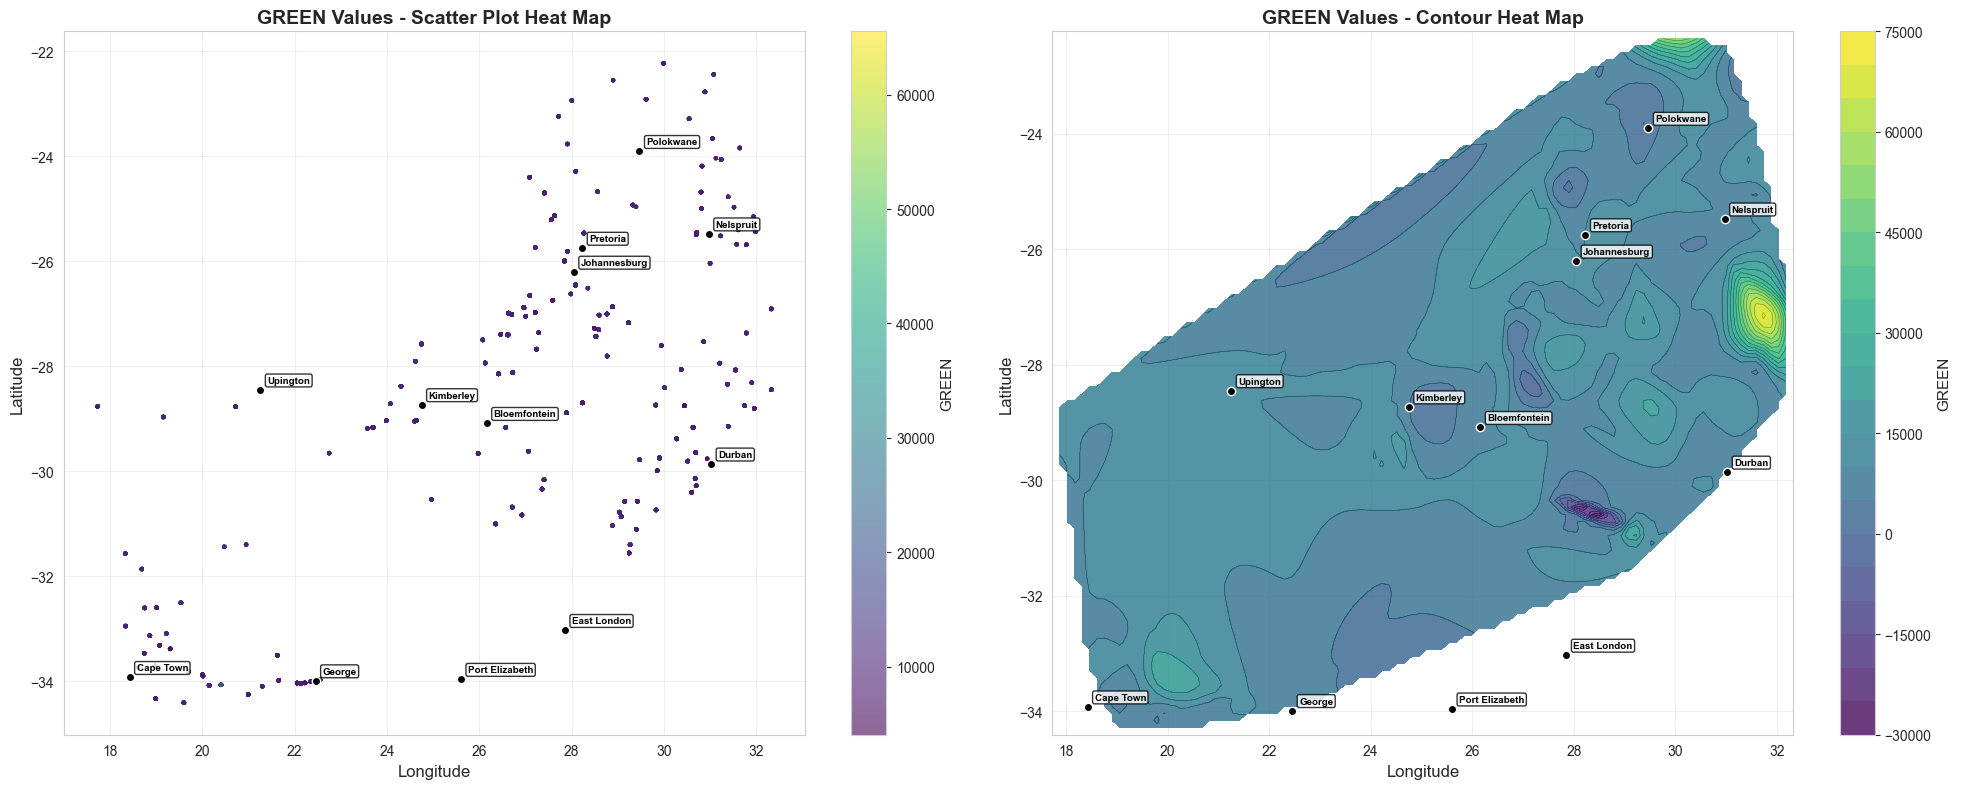


GREEN Statistics:
  Count: 8234
  Mean: 9983.2131
  Median: 9801.0000
  Std: 2778.7802
  Min: 4045.0000
  Max: 65535.0000
  Missing values: 0
----------------------------------------------------------------------


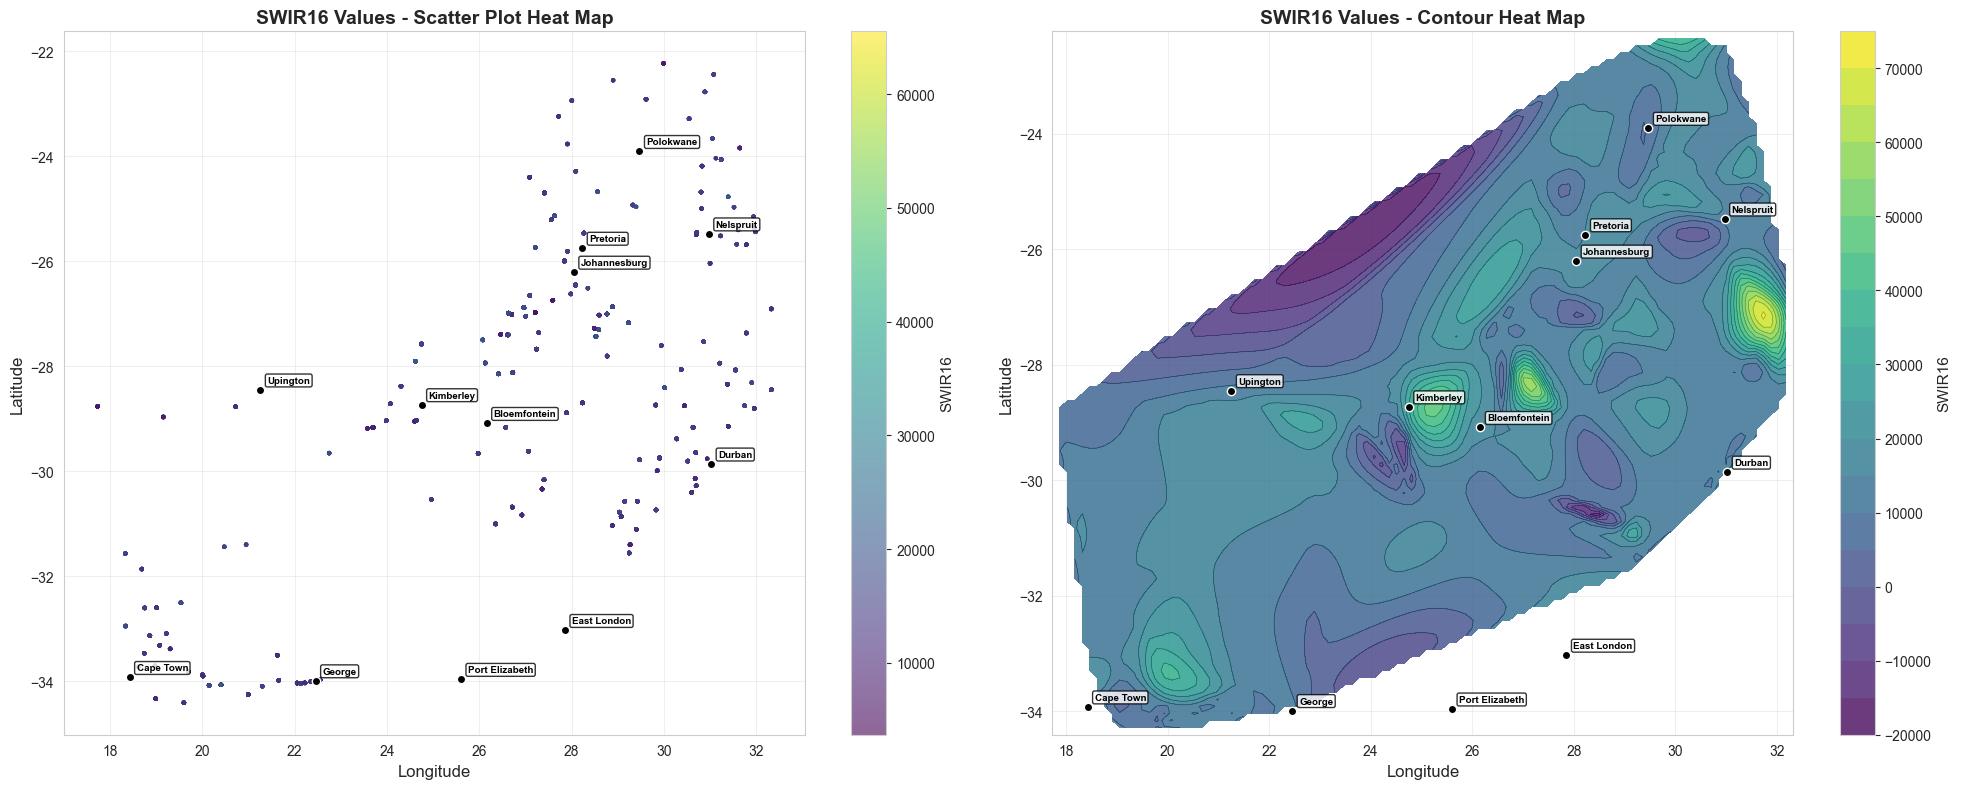


SWIR16 Statistics:
  Count: 8234
  Mean: 13567.4593
  Median: 13704.2500
  Std: 3348.5177
  Min: 3672.5000
  Max: 65535.0000
  Missing values: 0
----------------------------------------------------------------------


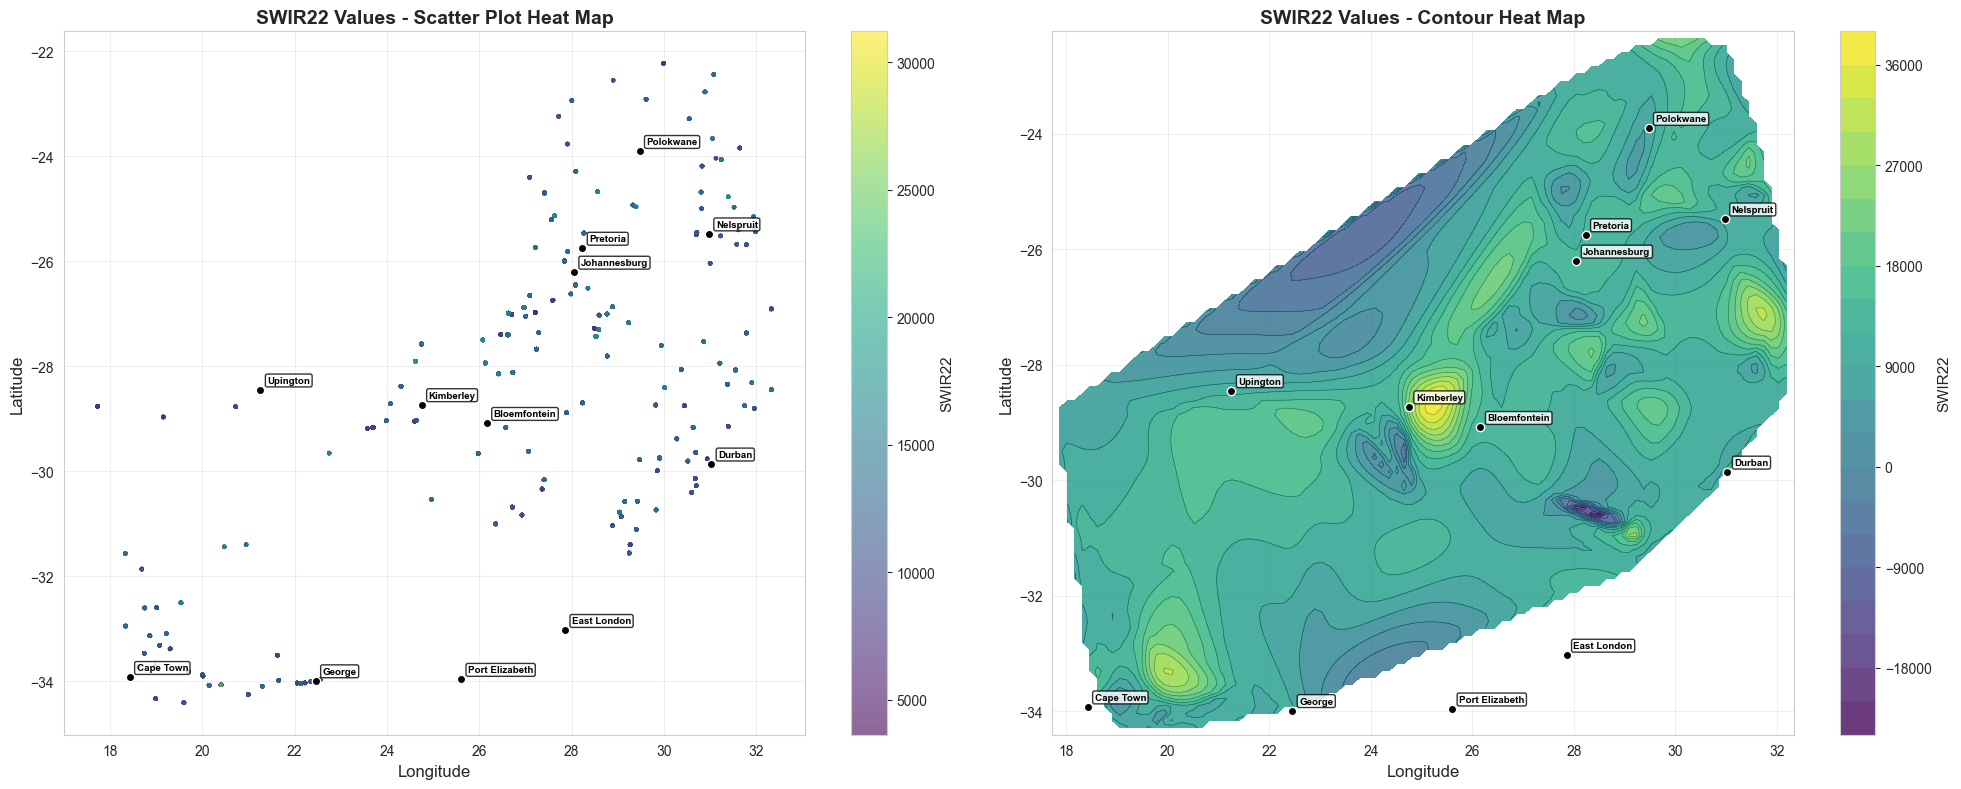


SWIR22 Statistics:
  Count: 8234
  Mean: 11425.5384
  Median: 11265.2500
  Std: 2548.1935
  Min: 3634.0000
  Max: 31202.5000
  Missing values: 0
----------------------------------------------------------------------


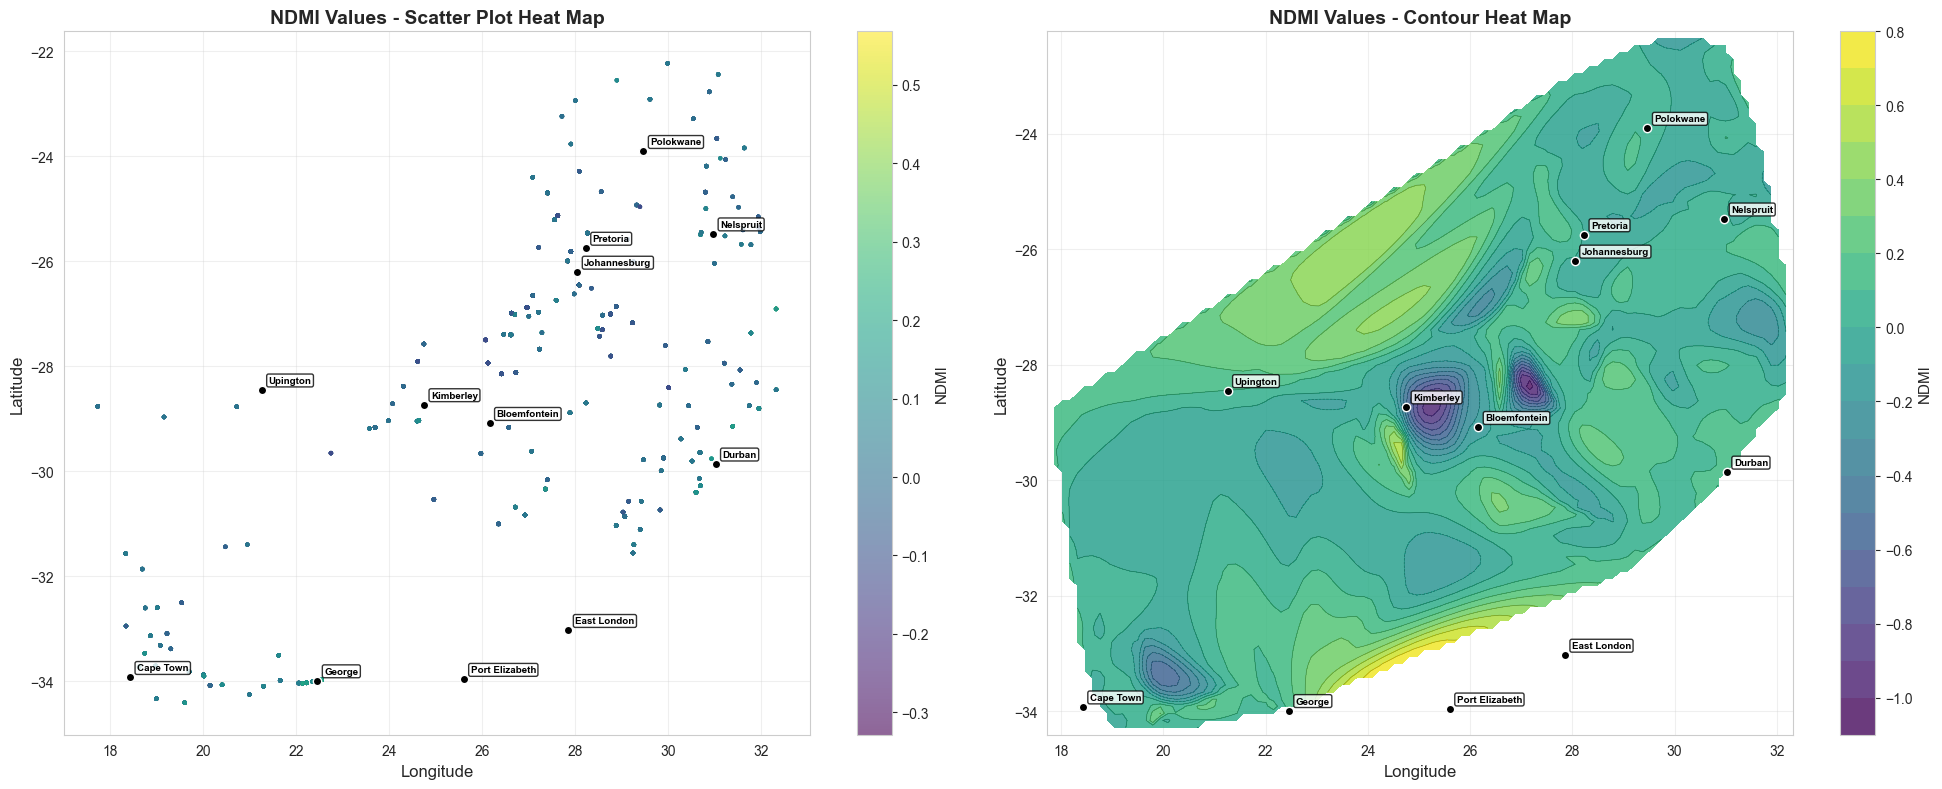


NDMI Statistics:
  Count: 8234
  Mean: 0.0214
  Median: 0.0215
  Std: 0.0779
  Min: -0.3283
  Max: 0.5679
  Missing values: 0
----------------------------------------------------------------------


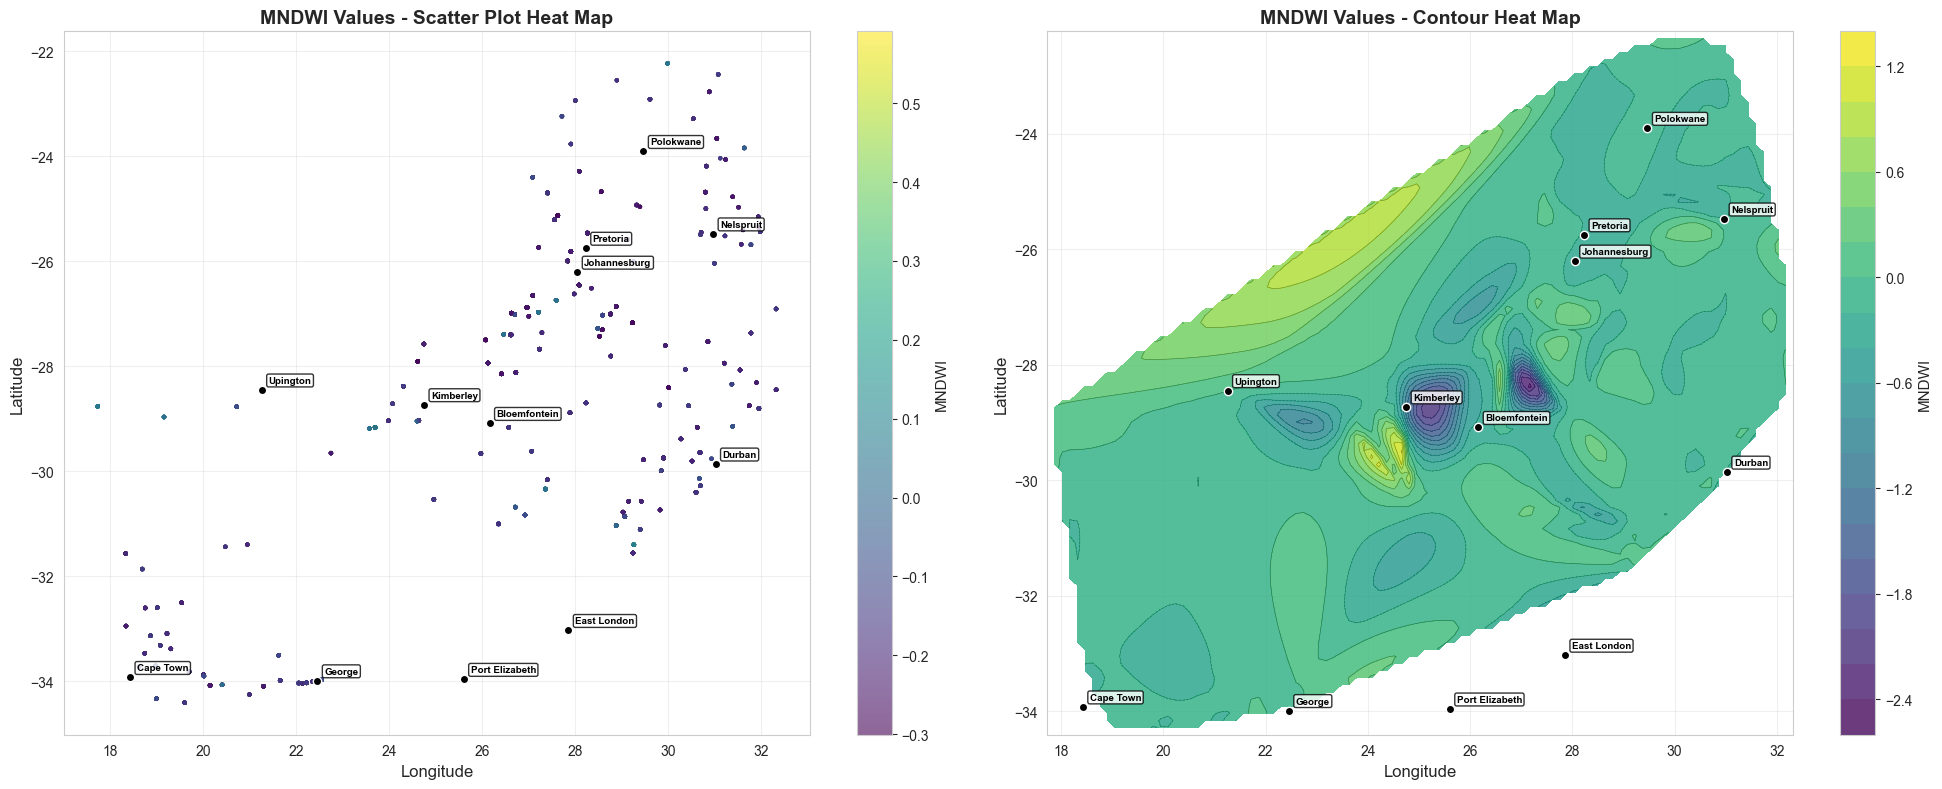


MNDWI Statistics:
  Count: 8234
  Mean: -0.1443
  Median: -0.1679
  Std: 0.0976
  Min: -0.3005
  Max: 0.5910
  Missing values: 0
----------------------------------------------------------------------


In [9]:
# Create scatter plots and contour heat maps for each Landsat feature

# Use the cleaned training data
# landsat_train_cleaned is already available from the cleaning cell

# Define prominent South African cities with their coordinates (for reference on map)
south_african_cities = {
    'Cape Town': [-33.9249, 18.4241],
    'Johannesburg': [-26.2041, 28.0473],
    'Durban': [-29.8587, 31.0218],
    'Pretoria': [-25.7479, 28.2293],
    'Port Elizabeth': [-33.9608, 25.6022],
    'Bloemfontein': [-29.0852, 26.1596],
    'East London': [-33.0292, 27.8546],
    'Polokwane': [-23.9045, 29.4689],
    'Nelspruit': [-25.4745, 30.9703],
    'Kimberley': [-28.7282, 24.7497],
    'George': [-33.9881, 22.4536],
    'Upington': [-28.4478, 21.2561]
}

# Landsat features to visualize
landsat_features = ['nir', 'green', 'swir16', 'swir22', 'NDMI', 'MNDWI']

# Remove rows with missing values for any of these features for visualization
landsat_for_viz = landsat_train_cleaned.dropna(subset=landsat_features + ['Latitude', 'Longitude'])

print(f"Creating visualizations for {len(landsat_for_viz)} samples with complete feature data")
print(f"Features to visualize: {', '.join(landsat_features)}")

# Create visualizations for each feature
from scipy.interpolate import griddata

# Create a grid for interpolation (same for all features)
lon_min, lon_max = landsat_for_viz['Longitude'].min(), landsat_for_viz['Longitude'].max()
lat_min, lat_max = landsat_for_viz['Latitude'].min(), landsat_for_viz['Latitude'].max()
lon_grid = np.linspace(lon_min, lon_max, 100)
lat_grid = np.linspace(lat_min, lat_max, 100)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Create figure for each feature (scatter + contour)
for feature in landsat_features:
    # Remove missing values for this specific feature
    feature_data = landsat_for_viz.dropna(subset=[feature])
    
    if len(feature_data) == 0:
        print(f"Skipping {feature} - no valid data")
        continue
    
    # Create figure with scatter and contour plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # 1. Scatter plot colored by feature values
    scatter = axes[0].scatter(feature_data['Longitude'], 
                             feature_data['Latitude'], 
                             c=feature_data[feature], 
                             cmap='viridis', s=10, alpha=0.6, edgecolors='none')
    axes[0].set_xlabel('Longitude', fontsize=12)
    axes[0].set_ylabel('Latitude', fontsize=12)
    axes[0].set_title(f'{feature.upper()} Values - Scatter Plot Heat Map', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    cbar1 = plt.colorbar(scatter, ax=axes[0])
    cbar1.set_label(feature.upper(), fontsize=11)
    
    # Add city markers
    for city_name, (lat, lon) in south_african_cities.items():
        axes[0].plot(lon, lat, 'ko', markersize=6, markeredgecolor='white', markeredgewidth=1)
        axes[0].annotate(city_name, (lon, lat), xytext=(5, 5), textcoords='offset points', 
                        fontsize=7, fontweight='bold', color='black',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='black'))
    
    # 2. Contour plot of feature values
    try:
        # Interpolate feature values onto the grid
        feature_grid = griddata((feature_data['Longitude'], feature_data['Latitude']),
                                feature_data[feature],
                                (lon_mesh, lat_mesh), method='cubic')
        
        # Create contour plot
        contour = axes[1].contourf(lon_mesh, lat_mesh, feature_grid, levels=20, cmap='viridis', alpha=0.8)
        axes[1].contour(lon_mesh, lat_mesh, feature_grid, levels=20, colors='black', alpha=0.3, linewidths=0.5)
        axes[1].set_xlabel('Longitude', fontsize=12)
        axes[1].set_ylabel('Latitude', fontsize=12)
        axes[1].set_title(f'{feature.upper()} Values - Contour Heat Map', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        cbar2 = plt.colorbar(contour, ax=axes[1])
        cbar2.set_label(feature.upper(), fontsize=11)
        
        # Add city markers
        for city_name, (lat, lon) in south_african_cities.items():
            axes[1].plot(lon, lat, 'ko', markersize=6, markeredgecolor='white', markeredgewidth=1)
            axes[1].annotate(city_name, (lon, lat), xytext=(5, 5), textcoords='offset points', 
                            fontsize=7, fontweight='bold', color='black',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='black'))
    except Exception as e:
        print(f"Warning: Could not create contour plot for {feature}: {e}")
        axes[1].text(0.5, 0.5, f'Contour plot unavailable\nfor {feature}', 
                    ha='center', va='center', transform=axes[1].transAxes, fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics for this feature
    print(f"\n{feature.upper()} Statistics:")
    print(f"  Count: {len(feature_data)}")
    print(f"  Mean: {feature_data[feature].mean():.4f}")
    print(f"  Median: {feature_data[feature].median():.4f}")
    print(f"  Std: {feature_data[feature].std():.4f}")
    print(f"  Min: {feature_data[feature].min():.4f}")
    print(f"  Max: {feature_data[feature].max():.4f}")
    print(f"  Missing values: {landsat_for_viz[feature].isnull().sum()}")
    print("-" * 70)